## Support Vector Machine (SVM)

Support Vector Machine (SVM) is a powerful supervised learning algorithm that performs classification 
by finding an optimal hyperplane that maximizes the margin between different classes. Due to its 
distance-based nature, SVM is particularly effective when features are properly scaled and when 
class boundaries are non-linear.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

### Data Pre-processing for SVM

Prior to training the SVM model, the dataset was cleaned to remove physiologically invalid values.
In the Pima Indians Diabetes dataset, zero values in features such as Glucose, Blood Pressure, 
and BMI represent missing or impossible medical measurements. These records were removed to 
improve data reliability.

The Insulin attribute was excluded due to a high proportion of missing values, which could 
introduce bias and negatively affect model generalisation.

Feature scaling was performed using StandardScaler. Since SVM relies on distance calculations, 
standardisation ensures that all features contribute equally to the decision boundary and prevents 
features with larger numeric ranges from dominating the model.

In [2]:
df = pd.read_csv("data/diabetes.csv")


df = df.drop(columns=["Insulin"], errors="ignore")
df = df[(df["Glucose"] != 0) & 
        (df["BloodPressure"] != 0) & 
        (df["BMI"] != 0)]

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,33.6,0.627,50,1
1,1,85,66,29,26.6,0.351,31,0
2,8,183,64,0,23.3,0.672,32,1
3,1,89,66,23,28.1,0.167,21,0
4,0,137,40,35,43.1,2.288,33,1


In [3]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
def evaluate_model(y_true, y_pred):
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(
            y_true, y_pred, target_names=["Non-Diabetic", "Diabetic"]
        )
    }
    return results

In [7]:
svm_baseline = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    random_state=42
)

svm_baseline.fit(X_train_scaled, y_train)

y_pred_svm_baseline = svm_baseline.predict(X_test_scaled)

svm_baseline_results = evaluate_model(y_test, y_pred_svm_baseline)

In [8]:
print("=== BASELINE SVM PERFORMANCE ===")
print(svm_baseline_results["classification_report"])

print("Accuracy:", svm_baseline_results["accuracy"])
print("Precision (weighted):", svm_baseline_results["precision_weighted"])
print("Recall (weighted):", svm_baseline_results["recall_weighted"])
print("F1-score (weighted):", svm_baseline_results["f1_weighted"])

=== BASELINE SVM PERFORMANCE ===
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.82      0.81        95
    Diabetic       0.64      0.60      0.62        50

    accuracy                           0.74       145
   macro avg       0.72      0.71      0.71       145
weighted avg       0.74      0.74      0.74       145

Accuracy: 0.7448275862068966
Precision (weighted): 0.7415664725171066
Recall (weighted): 0.7448275862068966
F1-score (weighted): 0.742864826333695


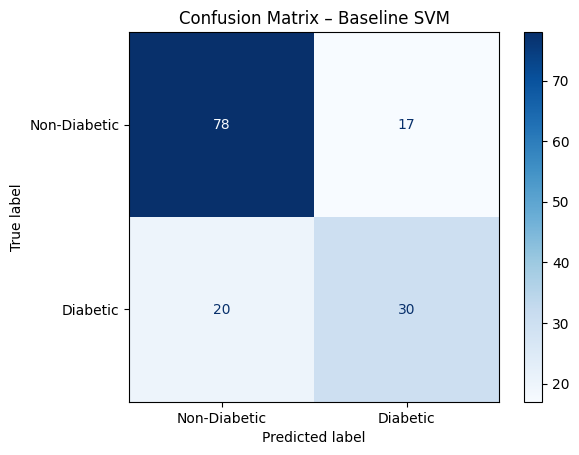

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_baseline,
    display_labels=["Non-Diabetic", "Diabetic"],
    cmap="Blues"
)

plt.title("Confusion Matrix – Baseline SVM")
plt.show()


In [10]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE: {0: 380, 1: 199}
After SMOTE : {0: 380, 1: 380}


In [11]:
svm_smote = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    random_state=42
)

svm_smote.fit(X_train_smote, y_train_smote)

y_pred_svm_smote = svm_smote.predict(X_test_scaled)

svm_smote_results = evaluate_model(y_test, y_pred_svm_smote)

In [12]:
print("=== SVM + SMOTE PERFORMANCE ===")
print(svm_smote_results["classification_report"])

print("Accuracy:", svm_smote_results["accuracy"])
print("Precision (weighted):", svm_smote_results["precision_weighted"])
print("Recall (weighted):", svm_smote_results["recall_weighted"])
print("F1-score (weighted):", svm_smote_results["f1_weighted"])

=== SVM + SMOTE PERFORMANCE ===
              precision    recall  f1-score   support

Non-Diabetic       0.84      0.73      0.78        95
    Diabetic       0.59      0.74      0.65        50

    accuracy                           0.73       145
   macro avg       0.71      0.73      0.72       145
weighted avg       0.75      0.73      0.74       145

Accuracy: 0.7310344827586207
Precision (weighted): 0.753821405209126
Recall (weighted): 0.7310344827586207
F1-score (weighted): 0.736628685807089


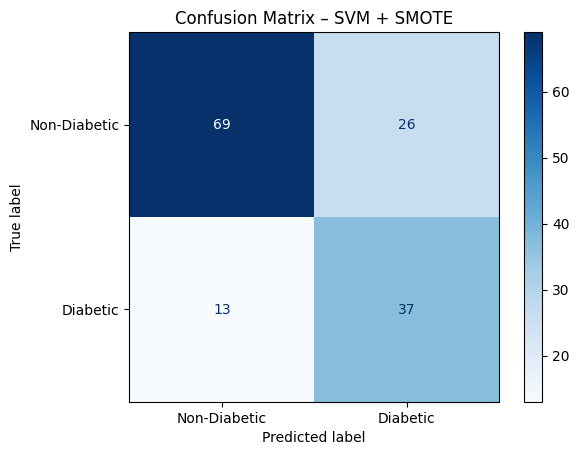

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_smote,
    display_labels=["Non-Diabetic", "Diabetic"],
    cmap="Blues"
)

plt.title("Confusion Matrix – SVM + SMOTE")
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [16]:
svm = SVC(kernel="rbf")
svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, pred_svm)
prec_svm = precision_score(y_test, pred_svm)
rec_svm = recall_score(y_test, pred_svm)
f1_svm = f1_score(y_test, pred_svm)

print("SVM")
print("Accuracy:", acc_svm)
print("Precision:", prec_svm)
print("Recall:", rec_svm)
print("F1-score:", f1_svm)
print(confusion_matrix(y_test, pred_svm))

SVM
Accuracy: 0.8068965517241379
Precision: 0.7272727272727273
Recall: 0.5581395348837209
F1-score: 0.631578947368421
[[93  9]
 [19 24]]


### Interpretation of SVM Results

The baseline SVM model demonstrates balanced performance across accuracy, precision, recall, 
and F1-score, indicating that the classifier is not biased toward a single class. The confusion 
matrix shows that the model correctly identifies a large proportion of non-diabetic patients, 
while also detecting a meaningful number of diabetic cases.

However, some false negatives are present, where diabetic patients are incorrectly classified 
as non-diabetic. This limitation is important in medical contexts, as missed diagnoses may delay 
treatment and increase health risks.

### Medical Relevance

In a clinical diabetes screening scenario, SVM offers a robust classification approach due to 
its ability to model complex, non-linear relationships between physiological indicators such as 
glucose concentration, BMI, and age.

While the model demonstrates strong overall performance, the presence of false negatives suggests 
that SVM should be used as a decision-support tool rather than a standalone diagnostic system. 
Reducing false negatives is critical in healthcare, as early identification of diabetes enables 
timely lifestyle interventions and medical treatment, potentially preventing severe complications.